In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


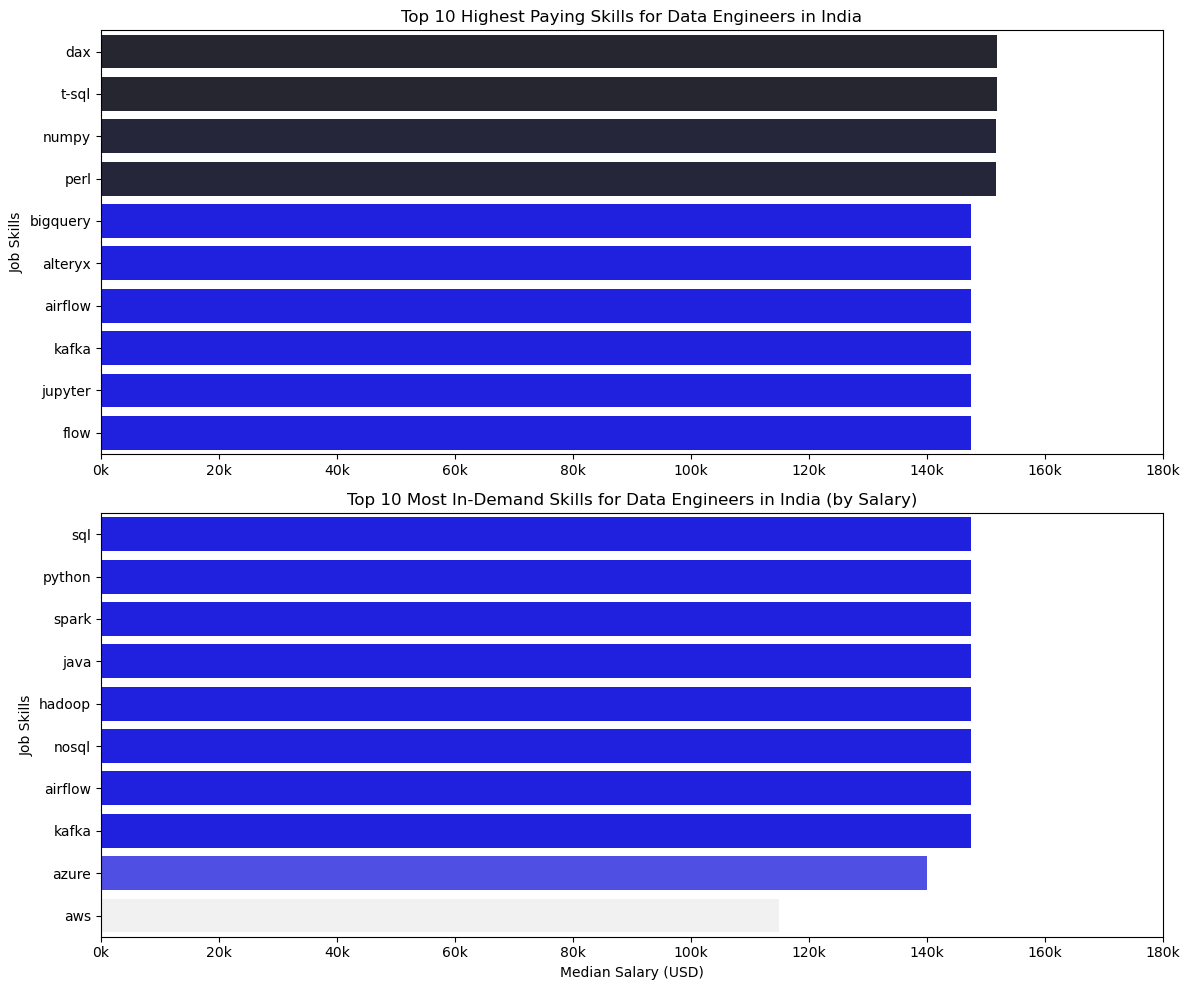

In [2]:
import seaborn as sns
import matplotlib.ticker as ticker

# Analysis of Data Engineer jobs in India
df_DE_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')].copy()

# Drop the null values from the column
df_DE_In = df_DE_In.dropna(subset=['salary_year_avg'])

# Explode the job skills column
df_DE_In = df_DE_In.explode('job_skills')

# Exploratory data analysis using the groupby method
df_DE_In_group = df_DE_In.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

# Sort highest to lowest for top pay (descending)
df_DE_top_pay = df_DE_In_group.sort_values(by='median', ascending=False).head(10)

# Sort by count, then by median for most in-demand (highest median at top)
df_DE_skills = df_DE_In_group.sort_values(by='count', ascending=False).head(10)
df_DE_skills = df_DE_skills.sort_values(by='median', ascending=False)

# Reset index for seaborn
df_DE_top_pay_plot = df_DE_top_pay.reset_index()
df_DE_skills_plot = df_DE_skills.reset_index()

# Plotting the two on top of each other
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# TOP PLOT - Highest paying skills
sns.barplot(
    data=df_DE_top_pay_plot, 
    x='median', 
    y='job_skills', 
    ax=ax[0], 
    hue='median',
    palette='dark:b_r')
ax[0].set_title('Top 10 Highest Paying Skills for Data Engineers in India', fontsize=12)
ax[0].set_xlabel('')
ax[0].set_ylabel('Job Skills')
ax[0].set_xlim(0, 180000)
ax[0].legend().remove()

# Format x-axis for top plot
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# BOTTOM PLOT - Most in-demand skills
sns.barplot(
    data=df_DE_skills_plot, 
    x='median', 
    y='job_skills', 
    ax=ax[1], 
    hue='median',
    palette='light:b')
ax[1].set_title('Top 10 Most In-Demand Skills for Data Engineers in India (by Salary)', fontsize=12)
ax[1].set_xlabel('Median Salary (USD)', fontsize=10)
ax[1].set_ylabel('Job Skills')
ax[1].legend().remove()

# Format x-axis for bottom plot
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Match x-axis limits
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()

Histogram using seaborn

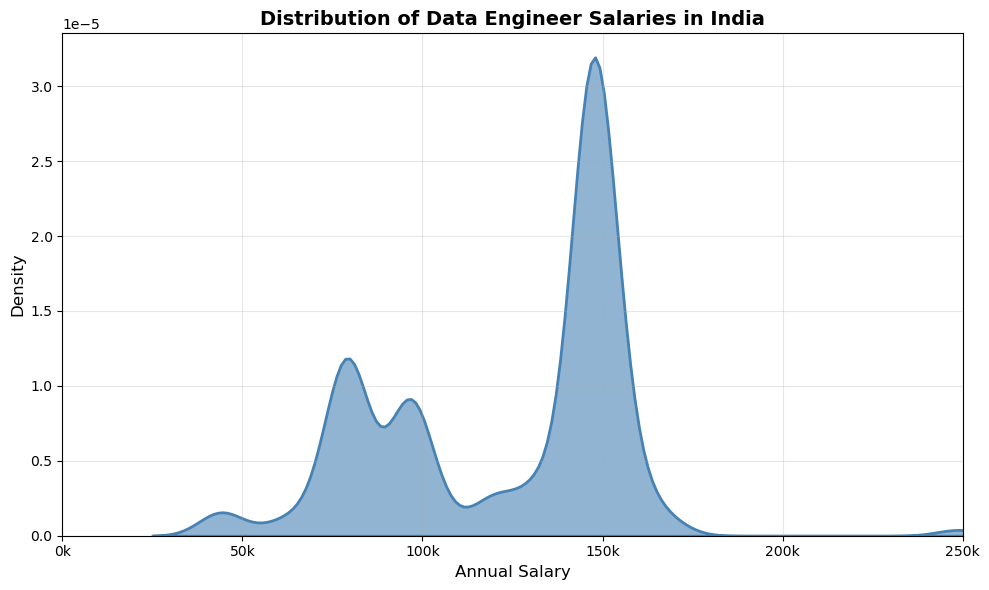

In [6]:
import seaborn as sns
import matplotlib.ticker as ticker

# Analysis of Data Engineer jobs in India
df_DE_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')].copy()

# Create smooth distribution plot using KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df_DE_In, x='salary_year_avg', bw_adjust=0.5, 
            fill=True, alpha=0.6, color='steelblue', linewidth=2, ax=ax)
ax.set_xlim(0, 250000)

# Format x-axis with FuncFormatter (show as 20k, 30k, 100k, etc.)
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Add labels and title
ax.set_xlabel('Annual Salary', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Data Engineer Salaries in India', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Boxplots using seaborn

C:\Users\Greg\AppData\Local\Temp\ipykernel_9712\51743665.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_In, x='salary_year_avg', y='job_title_short',


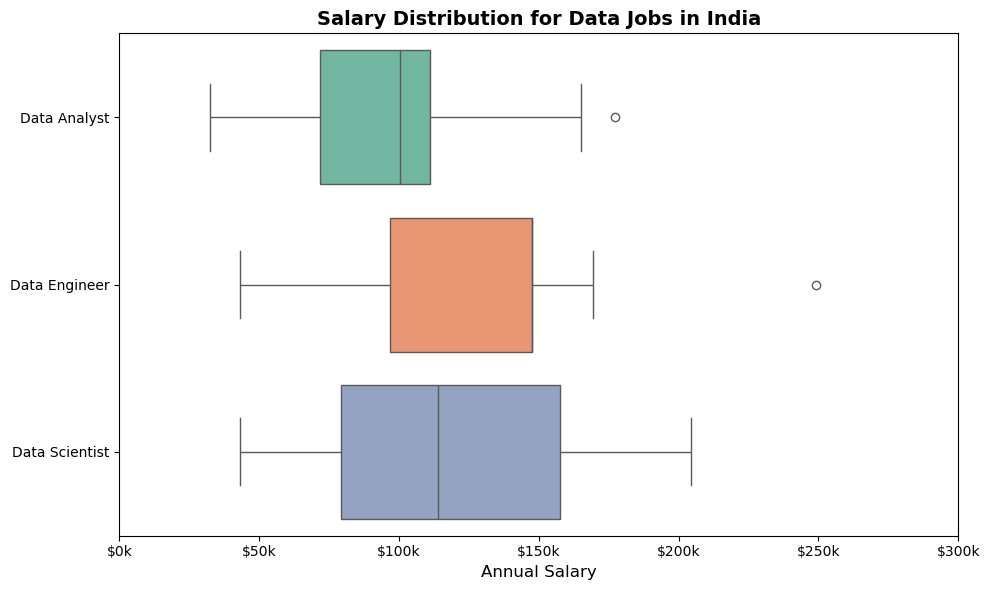

In [8]:
import seaborn as sns
import matplotlib.ticker as ticker

jobtitles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_In = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(jobtitles))].copy()

df_In = df_In.dropna(subset=['salary_year_avg'])

# Create boxplot using seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_In, x='salary_year_avg', y='job_title_short', 
            order=jobtitles, palette='Set2', ax=ax)

# Format x-axis with FuncFormatter (show as $20k, $30k, $100k, etc.)
def format_salary(x, pos):
    return f'${x/1000:.0f}k'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Add title and labels
ax.set_title('Salary Distribution for Data Jobs in India', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Salary', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, 300000)

plt.tight_layout()
plt.show()